In [1]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

# Add the root directory to the path so we can import from 'src'
sys.path.append(os.path.abspath('..'))

# Update this line to match your new utils.py
from src.utils import VisionExtractGenerator, dice_loss

In [3]:
from src.model import build_unet

# This line is what actually "builds" the architecture in memory
my_model = build_unet(input_shape=(256, 256, 3))

# This line checks if it was built correctly by showing the layers
my_model.summary()

Model: "VisionExtract_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [6]:
import tensorflow as tf  # Add this line to define 'tf'
import matplotlib.pyplot as plt
import numpy as np

class VisualizeProgress(tf.keras.callbacks.Callback):
    def __init__(self, generator):
        super().__init__()
        self.generator = generator

    def on_epoch_end(self, epoch, logs=None):
        # Only run every 5 epochs
        if (epoch + 1) % 5 == 0:
            # Get a batch of images and masks
            img_batch, mask_batch = self.generator[0]
            
            # Predict using the current state of the U-Net
            pred_mask = self.model.predict(img_batch, verbose=0)
            
            # Plot the results for the first image in the batch
            plt.figure(figsize=(12, 4))
            
            plt.subplot(1, 3, 1)
            plt.imshow(img_batch[0])
            plt.title(f"Epoch {epoch+1}: Original")
            plt.axis('off')
            
            plt.subplot(1, 3, 2)
            plt.imshow(mask_batch[0].squeeze(), cmap='gray')
            plt.title("Ground Truth Mask")
            plt.axis('off')
            
            plt.subplot(1, 3, 3)
            plt.imshow(pred_mask[0].squeeze(), cmap='gray')
            plt.title("Model Prediction")
            plt.axis('off')
            
            plt.show()

In [5]:
from src.utils import VisionExtractGenerator, dice_loss

# 1. Initialize Generators (Pointing to your 'processed' folders)
train_gen = VisionExtractGenerator('../data/processed/train', batch_size=16)
val_gen = VisionExtractGenerator('../data/processed/val', batch_size=16)

# 2. Compile
my_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=2, name='mean_iou')]
)

# 3. Training Callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('../models/vision_extract_best.keras', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=5, monitor='val_loss'),
    VisualizeProgress(val_gen)
]

# 4. Start Training
history = my_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 4659s 21s/step - accuracy: 0.6819 - loss: 0.4320 - mean_iou: 0.3491 - val_accuracy: 0.7056 - val_loss: 0.9442 - val_mean_iou: 0.3527
Epoch 2/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 4745s 22s/step - accuracy: 0.7217 - loss: 0.3834 - mean_iou: 0.3491 - val_accuracy: 0.7421 - val_loss: 0.6315 - val_mean_iou: 0.3527
Epoch 3/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 4508s 21s/step - accuracy: 0.7361 - loss: 0.3686 - mean_iou: 0.3491 - val_accuracy: 0.7624 - val_loss: 0.3883 - val_mean_iou: 0.3527
Epoch 4/5
  1/218 ━━━━━━━━━━━━━━━━━━━━ 1:07:49 19s/step - accuracy: 0.7362 - loss: 0.3586 - mean_iou: 0.3591

KeyboardInterrupt: 

Epoch 4/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 5221s 24s/step - accuracy: 0.7462 - loss: 0.3575 - mean_iou: 0.3491 - val_accuracy: 0.7377 - val_loss: 0.3611 - val_mean_iou: 0.3527
Epoch 5/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 32s/step - accuracy: 0.7565 - loss: 0.3465 - mean_iou: 0.3486 

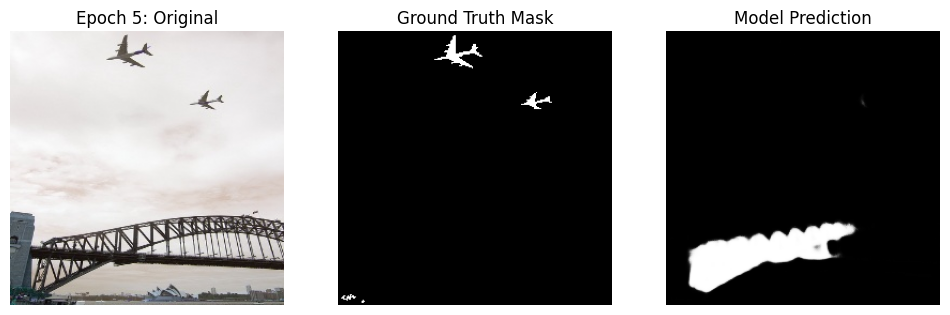

218/218 ━━━━━━━━━━━━━━━━━━━━ 7164s 33s/step - accuracy: 0.7588 - loss: 0.3462 - mean_iou: 0.3491 - val_accuracy: 0.7756 - val_loss: 0.3848 - val_mean_iou: 0.3527


In [4]:
import sys
import os

# 1. Path Fix: Tell Python to look one level up for the 'src' folder
sys.path.append(os.path.abspath('..'))

import tensorflow as tf
from src.utils import VisionExtractGenerator, dice_loss

# 2. Load the Best Model from your models folder
# This picks up all the weights learned during Epochs 1-3
my_model = tf.keras.models.load_model(
    '../models/vision_extract_best.keras',
    custom_objects={'dice_loss': dice_loss}
)

# 3. Initialize Generators with Batch Size 16
# Your fresh RAM after the restart should handle this easily
train_gen = VisionExtractGenerator('../data/processed/train', batch_size=16)
val_gen = VisionExtractGenerator('../data/processed/val', batch_size=16)

# 4. Re-define Callbacks
# We must re-define these because the kernel restart cleared them from memory
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('../models/vision_extract_best.keras', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=3, monitor='val_loss'),
    # Note: Ensure VisualizeProgress is imported or defined in your notebook
    VisualizeProgress(val_gen) 
]

# 5. Resume and finish exactly at Epoch 5
# initial_epoch=3 means 0,1,2 are done. epochs=5 stops after the 5th
history = my_model.fit(
    train_gen,
    validation_data=val_gen,
    initial_epoch=3, 
    epochs=5,
    callbacks=callbacks
)

In [5]:
import sys
import os

# 1. Path Fix: Tell Python to look one level up for the 'src' folder
sys.path.append(os.path.abspath('..'))

import tensorflow as tf
from src.utils import VisionExtractGenerator, dice_loss

# 2. Load the Best Model from your models folder
# This picks up all the weights learned during Epochs 1-3
my_model = tf.keras.models.load_model(
    '../models/vision_extract_best.keras',
    custom_objects={'dice_loss': dice_loss}
)

# 3. Initialize Generators with Batch Size 16
# Your fresh RAM after the restart should handle this easily
train_gen = VisionExtractGenerator('../data/processed/train', batch_size=16)
val_gen = VisionExtractGenerator('../data/processed/val', batch_size=16)

# 4. Re-define Callbacks
# We must re-define these because the kernel restart cleared them from memory
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('../models/vision_extract_best.keras', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=3, monitor='val_loss'),
    # Note: Ensure VisualizeProgress is imported or defined in your notebook
    VisualizeProgress(val_gen) 
]

# 5. Resume and finish exactly at Epoch 5
# initial_epoch=3 means 0,1,2 are done. epochs=5 stops after the 5th
history = my_model.fit(
    train_gen,
    validation_data=val_gen,
    initial_epoch=5, 
    epochs=10,
    callbacks=callbacks
)

Epoch 6/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 5744s 26s/step - accuracy: 0.7571 - loss: 0.3493 - mean_iou: 0.3491 - val_accuracy: 0.7617 - val_loss: 0.3717 - val_mean_iou: 0.3527
Epoch 7/10
 11/218 ━━━━━━━━━━━━━━━━━━━━ 1:11:11 21s/step - accuracy: 0.7719 - loss: 0.3270 - mean_iou: 0.3543

KeyboardInterrupt: 

Epoch 7/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 4464s 20s/step - accuracy: 0.7642 - loss: 0.3396 - mean_iou: 0.3491 - val_accuracy: 0.7804 - val_loss: 0.3576 - val_mean_iou: 0.3527
Epoch 8/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 4482s 21s/step - accuracy: 0.7707 - loss: 0.3337 - mean_iou: 0.3491 - val_accuracy: 0.7770 - val_loss: 0.3559 - val_mean_iou: 0.3527
Epoch 9/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 4482s 21s/step - accuracy: 0.7756 - loss: 0.3271 - mean_iou: 0.3491 - val_accuracy: 0.7735 - val_loss: 0.3356 - val_mean_iou: 0.3527
Epoch 10/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 20s/step - accuracy: 0.7832 - loss: 0.3155 - mean_iou: 0.3468 

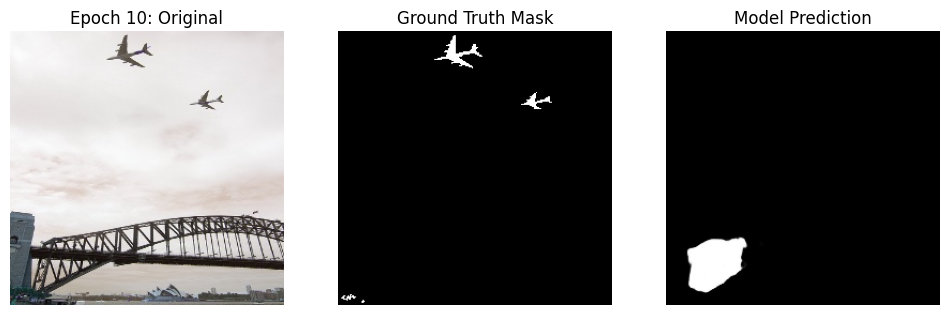

218/218 ━━━━━━━━━━━━━━━━━━━━ 4522s 21s/step - accuracy: 0.7856 - loss: 0.3171 - mean_iou: 0.3491 - val_accuracy: 0.7801 - val_loss: 0.3422 - val_mean_iou: 0.3527


In [3]:
import sys
import os

# 1. Path Fix: Tell Python to look one level up for the 'src' folder
sys.path.append(os.path.abspath('..'))

import tensorflow as tf
from src.utils import VisionExtractGenerator, dice_loss

# 2. Load the Best Model from your models folder
# This picks up all the weights learned during Epochs 1-3
my_model = tf.keras.models.load_model(
    '../models/vision_extract_best.keras',
    custom_objects={'dice_loss': dice_loss}
)

# 3. Initialize Generators with Batch Size 16
# Your fresh RAM after the restart should handle this easily
train_gen = VisionExtractGenerator('../data/processed/train', batch_size=16)
val_gen = VisionExtractGenerator('../data/processed/val', batch_size=16)

# 4. Re-define Callbacks
# We must re-define these because the kernel restart cleared them from memory
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('../models/vision_extract_best.keras', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=3, monitor='val_loss'),
    # Note: Ensure VisualizeProgress is imported or defined in your notebook
    VisualizeProgress(val_gen) 
]

# 5. Resume and finish exactly at Epoch 5
# initial_epoch=3 means 0,1,2 are done. epochs=5 stops after the 5th
history = my_model.fit(
    train_gen,
    validation_data=val_gen,
    initial_epoch=6, 
    epochs=10,
    callbacks=callbacks
)

Epoch 11/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 16442s 76s/step - accuracy: 0.7824 - loss: 0.3194 - mean_iou: 0.3491 - val_accuracy: 0.7218 - val_loss: 0.3596 - val_mean_iou: 0.3527
Epoch 12/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 5373s 25s/step - accuracy: 0.7867 - loss: 0.3147 - mean_iou: 0.3491 - val_accuracy: 0.7206 - val_loss: 0.3574 - val_mean_iou: 0.3527
Epoch 13/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 5757s 26s/step - accuracy: 0.7920 - loss: 0.3093 - mean_iou: 0.3491 - val_accuracy: 0.7742 - val_loss: 0.3393 - val_mean_iou: 0.3527
Epoch 14/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 5956s 27s/step - accuracy: 0.7985 - loss: 0.3013 - mean_iou: 0.3491 - val_accuracy: 0.7934 - val_loss: 0.3329 - val_mean_iou: 0.3527
Epoch 15/15
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 28s/step - accuracy: 0.8035 - loss: 0.2991 - mean_iou: 0.3514 

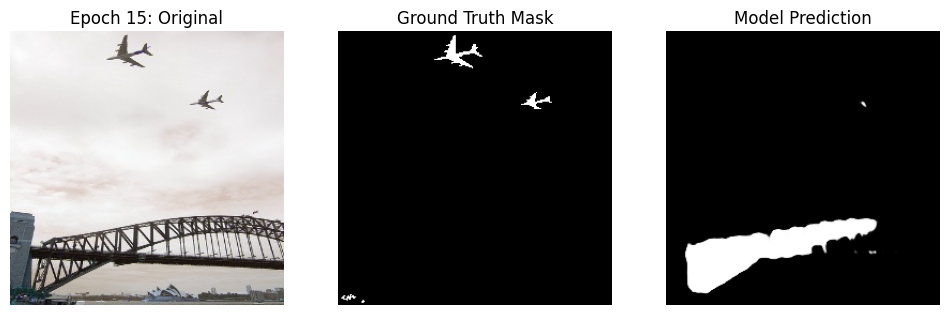

218/218 ━━━━━━━━━━━━━━━━━━━━ 6364s 29s/step - accuracy: 0.8020 - loss: 0.2981 - mean_iou: 0.3491 - val_accuracy: 0.7936 - val_loss: 0.3230 - val_mean_iou: 0.3527


In [2]:
import sys
import os

# 1. Path Fix: Tell Python to look one level up for the 'src' folder
sys.path.append(os.path.abspath('..'))

import tensorflow as tf
from src.utils import VisionExtractGenerator, dice_loss

# 2. Load the Best Model from your models folder
# This picks up all the weights learned during Epochs 1-3
my_model = tf.keras.models.load_model(
    '../models/vision_extract_best.keras',
    custom_objects={'dice_loss': dice_loss}
)

# 3. Initialize Generators with Batch Size 16
# Your fresh RAM after the restart should handle this easily
train_gen = VisionExtractGenerator('../data/processed/train', batch_size=16)
val_gen = VisionExtractGenerator('../data/processed/val', batch_size=16)

# 4. Re-define Callbacks
# We must re-define these because the kernel restart cleared them from memory
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('../models/vision_extract_best.keras', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=3, monitor='val_loss'),
    # Note: Ensure VisualizeProgress is imported or defined in your notebook
    VisualizeProgress(val_gen) 
]

# 5. Resume and finish exactly at Epoch 5
# initial_epoch=3 means 0,1,2 are done. epochs=5 stops after the 5th
history = my_model.fit(
    train_gen,
    validation_data=val_gen,
    initial_epoch=10, 
    epochs=15,
    callbacks=callbacks
)

Starting fine-tuning with thresholded IoU monitoring...
Epoch 1/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 7350s 34s/step - accuracy: 0.7605 - bg_iou: 0.6895 - loss: 0.3501 - mean_iou: 0.5870 - subject_iou: 0.4846 - val_accuracy: 0.7923 - val_bg_iou: 0.7394 - val_loss: 0.3465 - val_mean_iou: 0.6153 - val_subject_iou: 0.4912
Epoch 2/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 8689s 40s/step - accuracy: 0.7655 - bg_iou: 0.6948 - loss: 0.3431 - mean_iou: 0.5938 - subject_iou: 0.4928 - val_accuracy: 0.7847 - val_bg_iou: 0.7229 - val_loss: 0.3335 - val_mean_iou: 0.6138 - val_subject_iou: 0.5048
Epoch 3/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 8078s 37s/step - accuracy: 0.7700 - bg_iou: 0.7005 - loss: 0.3382 - mean_iou: 0.5993 - subject_iou: 0.4982 - val_accuracy: 0.7866 - val_bg_iou: 0.7262 - val_loss: 0.3342 - val_mean_iou: 0.6153 - val_subject_iou: 0.5044
Epoch 4/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 8213s 37s/step - accuracy: 0.7733 - bg_iou: 0.7047 - loss: 0.3346 - mean_iou: 0.6034 - subject_iou: 0.5022 - val_accuracy: 0.7802 -

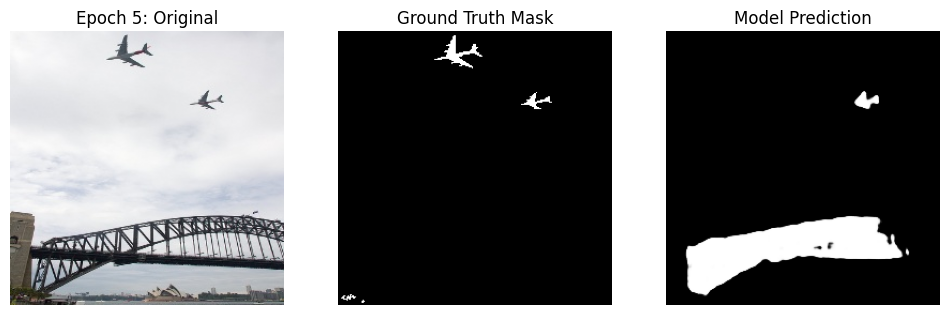

218/218 ━━━━━━━━━━━━━━━━━━━━ 7999s 37s/step - accuracy: 0.7752 - bg_iou: 0.7066 - loss: 0.3317 - mean_iou: 0.6061 - subject_iou: 0.5055 - val_accuracy: 0.7961 - val_bg_iou: 0.7415 - val_loss: 0.3340 - val_mean_iou: 0.6235 - val_subject_iou: 0.5054


In [8]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import tensorflow as tf
from src.utils1 import VisionExtractFineTuneGenerator, dice_loss

# 1. Initialize Generators
train_gen = VisionExtractFineTuneGenerator('../data/processed/train', batch_size=16)
val_gen = VisionExtractFineTuneGenerator('../data/processed/val', batch_size=16)

# 2. Load the model
model_path = '../models/vision_extract_best.keras'
my_model = tf.keras.models.load_model(model_path, custom_objects={'dice_loss': dice_loss})

# 3. Compile with Comprehensive IoU Metrics
my_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss=dice_loss,
    metrics=[
        'accuracy',
        # Background IoU (Class 0)
        tf.keras.metrics.BinaryIoU(target_class_ids=[0], threshold=0.3, name='bg_iou'),
        # Subject IoU (Class 1)
        tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.3, name='subject_iou'),
        # Mean IoU using a threshold to ensure it doesn't get stuck at 0.35
        tf.keras.metrics.BinaryIoU(target_class_ids=[0, 1], threshold=0.3, name='mean_iou')
    ]
)

# 4. Callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        '../models/vision_extract_fine_tuning.keras', 
        save_best_only=True, 
        monitor='val_subject_iou', 
        mode='max'
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=3, 
        monitor='val_subject_iou', 
        mode='max',
        restore_best_weights=True
    ),
    VisualizeProgress(val_gen)
]

# 5. Start Fine-Tuning
print("Starting fine-tuning with thresholded IoU monitoring...")
history = my_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5, 
    callbacks=callbacks
)

In [ ]:
import os

image_folder = "../data/val2017"

total_images = len(os.listdir(image_folder))
print("Total Images:", total_images)


In [ ]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pycocotools.coco import COCO

# Paths
annotation_path = "../data/annotations/instances_val2017.json"
#train_dir = "../data/processed/train"
train_dir = "../data/val2017"
output_dir = "../data/processed/sample_binary_masks"

os.makedirs(output_dir, exist_ok=True)

# Load COCO
coco = COCO(annotation_path)

# Get image info once (optimization)
img_ids = coco.getImgIds()
img_infos = coco.loadImgs(img_ids)

# Get train images
train_images = os.listdir(train_dir)

# Select 5 random images
selected_images = random.sample(train_images, 5)

print("Selected Images:", selected_images)

for img_name in selected_images:

    # Find image info in JSON
    img_info = None
    for info in img_infos:
        if info["file_name"] == img_name:
            img_info = info
            break

    if img_info is None:
        print(f"Skipping {img_name}")
        continue

    img_id = img_info["id"]
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    # Create binary mask
    mask = np.zeros((img_info["height"], img_info["width"]), dtype=np.uint8)

    for ann in anns:
        mask = np.maximum(mask, coco.annToMask(ann))

    mask = mask * 255

    # Save mask
    mask_path = os.path.join(output_dir, img_name.replace(".jpg", ".png"))
    cv2.imwrite(mask_path, mask)

    # Load original image
    img_path = os.path.join(train_dir, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Apply mask
    masked_img = cv2.bitwise_and(img, img, mask=mask)

    # Display for THIS image
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Binary Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(masked_img)
    plt.title("Masked Output")
    plt.axis("off")

    plt.suptitle(img_name)
    plt.show()

print("Done!")


In [ ]:
import os
import cv2
import numpy as np
from pycocotools.coco import COCO
from tqdm.notebook import tqdm

# ================= PATH SETTINGS =================
BASE_PATH = "../data"   # Because notebook is inside notebooks/
ANNOTATION_FILE = os.path.join(BASE_PATH, "annotations/instances_val2017.json")
PROCESSED_FOLDER = os.path.join(BASE_PATH, "processed")
IMG_SIZE = 256
# =================================================

coco = COCO(ANNOTATION_FILE)


def create_binary_mask(img_id, height, width):
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)

    mask = np.zeros((height, width), dtype=np.uint8)

    for ann in anns:
        mask = np.maximum(mask, coco.annToMask(ann))

    return np.where(mask > 0, 255, 0).astype("uint8")


def preprocess_image(img, mask, split_type, img_name):

    save_base = os.path.join(PROCESSED_FOLDER, split_type)
    os.makedirs(save_base, exist_ok=True)

    # Resize
    resized_img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    resized_mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE),
                              interpolation=cv2.INTER_NEAREST)

    # Normalize
    normalized_img = resized_img / 255.0

    # Save processed outputs
    cv2.imwrite(os.path.join(save_base, img_name + "_resized.jpg"),
                cv2.cvtColor(resized_img, cv2.COLOR_RGB2BGR))

    cv2.imwrite(os.path.join(save_base, img_name + "_normalized.jpg"),
                (normalized_img * 255).astype(np.uint8))

    cv2.imwrite(os.path.join(save_base, img_name + "_mask.png"),
                resized_mask)

    # Subject isolation
    isolated = cv2.bitwise_and(resized_img, resized_img, mask=resized_mask)
    cv2.imwrite(os.path.join(save_base, img_name + "_isolated.jpg"),
                cv2.cvtColor(isolated, cv2.COLOR_RGB2BGR))

    # TRAIN AUGMENTATIONS ONLY
    if split_type == "train":

        h_flip = cv2.flip(resized_img, 1)
        cv2.imwrite(os.path.join(save_base, img_name + "_hflip.jpg"),
                    cv2.cvtColor(h_flip, cv2.COLOR_RGB2BGR))

        v_flip = cv2.flip(resized_img, 0)
        cv2.imwrite(os.path.join(save_base, img_name + "_vflip.jpg"),
                    cv2.cvtColor(v_flip, cv2.COLOR_RGB2BGR))

        center = (IMG_SIZE // 2, IMG_SIZE // 2)
        rot_matrix = cv2.getRotationMatrix2D(center, 30, 1.0)
        rotated = cv2.warpAffine(resized_img, rot_matrix,
                                 (IMG_SIZE, IMG_SIZE))
        cv2.imwrite(os.path.join(save_base, img_name + "_rot30.jpg"),
                    cv2.cvtColor(rotated, cv2.COLOR_RGB2BGR))

        bright = np.clip(normalized_img * 1.5, 0, 1)
        cv2.imwrite(os.path.join(save_base, img_name + "_bright.jpg"),
                    (bright * 255).astype(np.uint8))


def process_split(split_type):

    split_folder = os.path.join(PROCESSED_FOLDER, split_type)

    if not os.path.exists(split_folder):
        print(f"{split_type} folder not found!")
        return

    print(f"\nProcessing {split_type} images...")

    # ✅ Only process original images (avoid reprocessing)
    image_files = [
        f for f in os.listdir(split_folder)
        if f.endswith(".jpg") and
        "_resized" not in f and
        "_normalized" not in f and
        "_isolated" not in f and
        "_hflip" not in f and
        "_vflip" not in f and
        "_rot30" not in f and
        "_bright" not in f
    ]

    for file_name in tqdm(image_files):

        img_path = os.path.join(split_folder, file_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img_id = int(file_name.split(".")[0])

        img_info = coco.loadImgs(img_id)[0]
        height, width = img_info["height"], img_info["width"]

        mask = create_binary_mask(img_id, height, width)

        preprocess_image(img, mask, split_type, file_name.split(".")[0])


# ================= RUN =================

process_split("train")
process_split("val")
process_split("test")

print("\nPreprocessing Completed Successfully!")


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import random
import numpy as np

# ================= PATH SETUP =================

CURRENT_DIR = os.getcwd()
BASE_PATH = os.path.abspath(os.path.join(CURRENT_DIR, "..", "data"))

TRAIN_PATH = os.path.join(BASE_PATH, "processed", "train")
ORIGINAL_PATH = os.path.join(BASE_PATH, "val2017")  # original COCO images folder

print("Train Path:", TRAIN_PATH)
print("Original Path:", ORIGINAL_PATH)

# =============================================

files = os.listdir(TRAIN_PATH)

# Extract clean IDs
image_ids = list(set([f.split("_")[0].split(".")[0] for f in files]))

print("Total unique image IDs found:", len(image_ids))

sample_ids = random.sample(image_ids, 3)

for img_id in sample_ids:

    print(f"\nShowing outputs for Image ID: {img_id}")

    def safe_read(path, gray=False):
        if os.path.exists(path):
            return cv2.imread(path, 0 if gray else 1)
        else:
            return None

    # Load original image
    original = safe_read(os.path.join(ORIGINAL_PATH, f"{img_id}.jpg"))

    # Load processed images
    resized = safe_read(os.path.join(TRAIN_PATH, f"{img_id}_resized.jpg"))
    hflip = safe_read(os.path.join(TRAIN_PATH, f"{img_id}_hflip.jpg"))
    vflip = safe_read(os.path.join(TRAIN_PATH, f"{img_id}_vflip.jpg"))
    rot = safe_read(os.path.join(TRAIN_PATH, f"{img_id}_rot30.jpg"))
    mask = safe_read(os.path.join(TRAIN_PATH, f"{img_id}_mask.png"), gray=True)
    isolated = safe_read(os.path.join(TRAIN_PATH, f"{img_id}_isolated.jpg"))

    images_check = [original, resized, hflip, vflip, rot, mask, isolated]

    if any(img is None for img in images_check):
        print("Skipping incomplete image set.")
        continue

    # Convert BGR → RGB
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    resized = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    hflip = cv2.cvtColor(hflip, cv2.COLOR_BGR2RGB)
    vflip = cv2.cvtColor(vflip, cv2.COLOR_BGR2RGB)
    rot = cv2.cvtColor(rot, cv2.COLOR_BGR2RGB)
    isolated = cv2.cvtColor(isolated, cv2.COLOR_BGR2RGB)

    # Compute normalized & bright in memory
    normalized = resized / 255.0
    bright = np.clip(normalized * 1.5, 0, 1)

    # Plot 3x3 grid
    plt.figure(figsize=(18,14))

    titles = [
        "Original",
        "Resized",
        "Normalized",
        "H-Flip",
        "V-Flip",
        "Rotate 30°",
        "Brightened",
        "Binary Mask",
        "Subject Isolation"
    ]

    display_images = [
        original,
        resized,
        normalized,
        hflip,
        vflip,
        rot,
        bright,
        mask,
        isolated
    ]

    for i in range(9):
        plt.subplot(3,3,i+1)

        if i == 7:  # mask
            plt.imshow(display_images[i], cmap="gray")
        else:
            plt.imshow(display_images[i])

        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()
